In [11]:
import snp2cell
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

## read network

In [4]:
csvFile = pd.read_csv("../process/SNP/SNP2ell/20250211_network_table.csv",index_col=0)

In [6]:
csvFile['width']

0      1.000000
1      1.000000
2      1.000000
3      1.000000
4      1.000000
         ...   
270    1.003919
271    1.028519
272    1.077727
273    1.180673
274    1.127153
Name: width, Length: 275, dtype: float64

In [56]:
G = nx.from_pandas_edgelist(
        csvFile,
        source='TF',  # source column name
        target='gene',  # target column name
        edge_attr='width'  # weight column name (optional)
    )

In [57]:
G

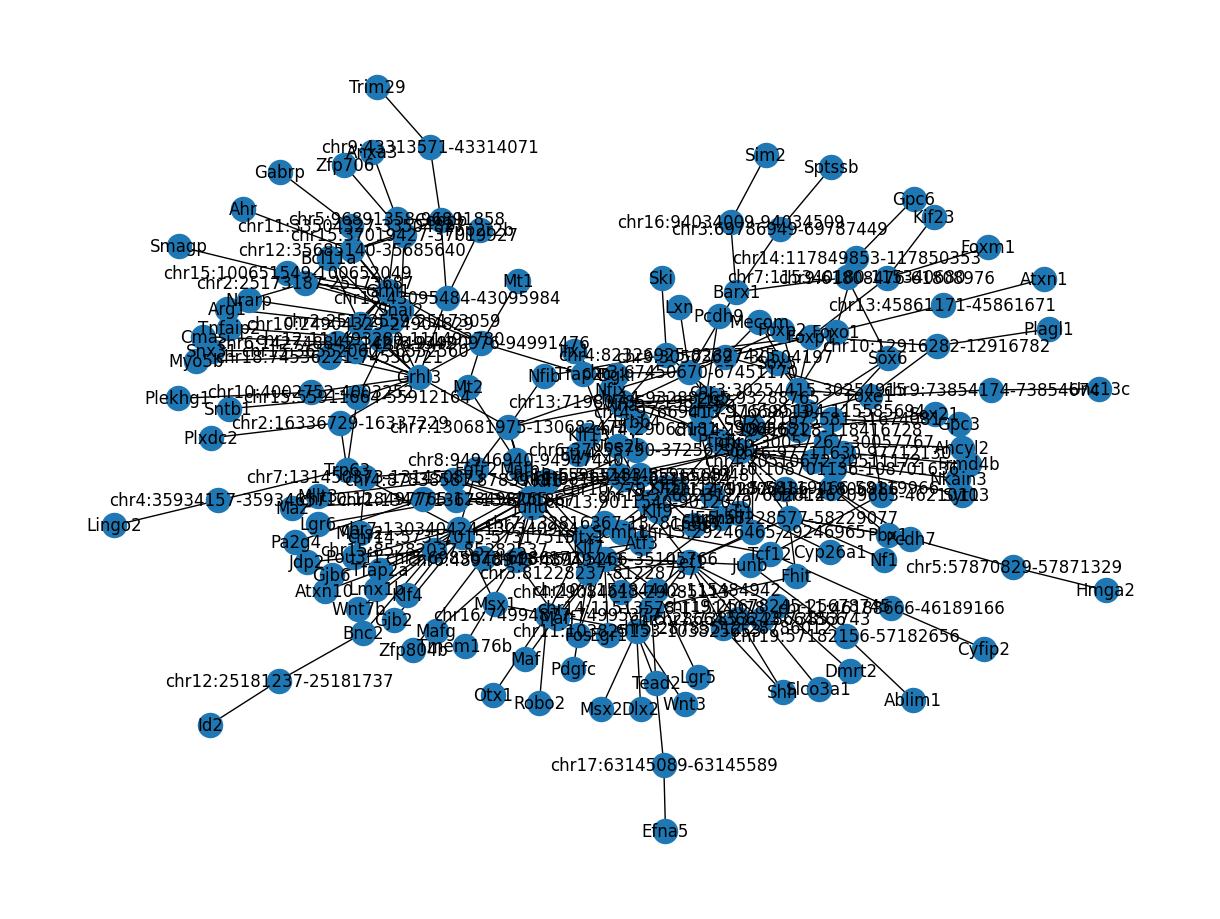

In [58]:
nx.draw_kamada_kawai(G, with_labels=True)

In [12]:
s2c = snp2cell.SNP2CELL()
s2c.add_grn_from_networkx(G)

In [14]:
s2c


GRN: Graph with 207 nodes and 275 edges
original scores: (207, 0)
propagated scores: (207, 0)
score perturbations for: None
anndata: None

In [16]:
snpscore = pd.read_csv("../process/framework/snps/20250213_SNPs_annoated_peaks_scenic.csv",index_col=0)

In [21]:
peak = snpscore["seqnames"] + ":" + snpscore["start"].astype(str) + "-" + snpscore["end"].astype(str)

In [23]:
snpscore['has_snp']

,seqnames,start,end,width,strand,has_snp
1,chr10,5466216,5466716,501,*,False
2,chr1,134289633,134290133,501,*,False
3,chr11,4848765,4849265,501,*,False
4,chr3,118561876,118562376,501,*,False
5,chr2,45894433,45894933,501,*,False
...,...,...,...,...,...,...
496509,chr15,89592551,89593051,501,*,False
496510,chr2,129176989,129177489,501,*,False
496511,chr15,83639203,83639703,501,*,False
496512,chr5,135835714,135836214,501,*,False


In [26]:
peak_snp_dict =  {k: v for k, v in zip(peak, snpscore['has_snp'])}

In [27]:
gene_snp = pd.read_csv("../process/SNP/SNP2ell/20250206_prepare_gene_snp.csv",index_col=0)

In [30]:
gene_snp

,seqnames,start,end,width,strand,gene_id,symbol,region_type,has_snp
1,chr9,21073096,21078096,5001,-,100009600,Zglp1,upstream,0
2,chr7,84964115,84969115,5001,-,100009609,Vmn2r65,upstream,0
3,chr10,77706457,77711457,5001,+,100009614,Krtap12-22,upstream,1
4,chr11,45803087,45808087,5001,+,100009664,F630206G17Rik,upstream,0
5,chr4,144162663,144167663,5001,-,100012,Oog3,upstream,0
...,...,...,...,...,...,...,...,...,...
49051,chr3,84496093,85887516,1391424,-,99889,Arfip1,gene_body,0
49052,chr3,110246109,110250998,4890,-,99890,Prmt6,gene_body,0
49053,chr3,151730922,151749960,19039,-,99899,Ifi44,gene_body,0
49054,chr3,65528410,65555518,27109,+,99929,Tiparp,gene_body,0


In [31]:
gene_snp_dict ={k: v for k, v in zip(gene_snp["symbol"], gene_snp['has_snp'])}

In [32]:
peak_snp_dict.update(gene_snp_dict)

## Load adata

In [36]:
ad = sc.read("../process/SNP/SNP2ell/20250213_prepare_rna.h5ad")

In [37]:
sc.pp.normalize_total(ad)
sc.pp.log1p(ad)
ad.raw = ad
sc.pp.scale(ad)
sc.pp.neighbors(ad)
sc.tl.umap(ad)

/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 23143 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


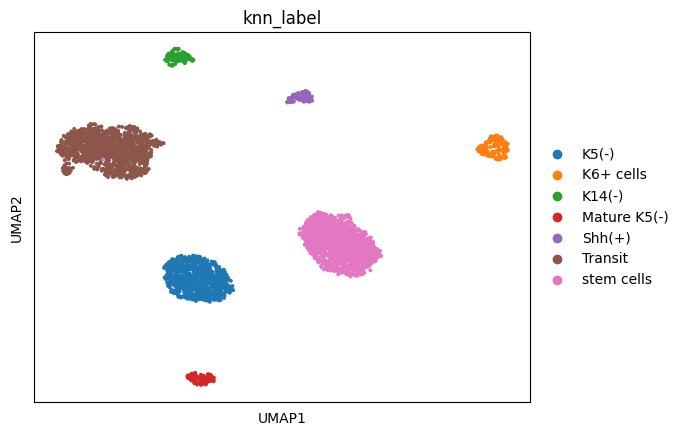

In [39]:
sc.pl.umap(ad, color=["knn_label"], cmap="Reds")

## Compute score

In [40]:
s2c.add_score(score_dct=peak_snp_dict, score_key="has_snp")

[INFO - add_score - 2025-02-13 11:57:52,369]: adding score: has_snp
[INFO - add_score - 2025-02-13 11:57:52,897]: propagating score: has_snp
[INFO - add_score - 2025-02-13 11:57:52,923]: storing score has_snp
[INFO - rand_sim - 2025-02-13 11:57:52,928]: ----- starting rand_sim -----
[INFO - rand_sim - 2025-02-13 11:57:52,930]: create 1000 permutations of score has_snp
[INFO - rand_sim - 2025-02-13 11:57:53,159]: propagating permutations
[INFO - loop_parallel - 2025-02-13 11:57:53,161]: using 48 cores
100%|██████████| 1000/1000 [00:13<00:00, 72.83it/s]
[INFO - rand_sim - 2025-02-13 11:58:08,417]: storing scores under key has_snp
[INFO - rand_sim - 2025-02-13 11:58:08,620]: ----- finished rand_sim -----
[INFO - add_score_statistics - 2025-02-13 11:58:08,626]: ----- starting add_score_statistics -----
[INFO - add_score_statistics - 2025-02-13 11:58:08,628]: adding statistics for: has_snp
[INFO - add_score_statistics - 2025-02-13 11:58:09,909]: ----- finished add_score_statistics -----


In [41]:
s2c.link_adata(ad)
s2c.adata_add_de_scores(groupby="knn_label", check=False)

[INFO - adata_add_de_scores - 2025-02-13 11:58:28,104]: ----- starting adata_add_de_scores -----
[INFO - adata_add_de_scores - 2025-02-13 11:58:28,108]: finding DE genes for annotation knn_label
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/zhanglab/micromamba/envs/py311/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_

In [43]:
s2c


GRN: Graph with 207 nodes and 275 edges
original scores: (207, 8)
propagated scores: (207, 40)
score perturbations for: ['has_snp', 'DE_knn_label__score']
anndata: (3756, 23143)

In [44]:
s2c.adata_combine_de_scores(
    group_key="knn_label", score_key="has_snp", suffix="__zscore"
)

[INFO - combine_scores - 2025-02-13 12:01:05,998]: ----- starting combine_scores -----
[INFO - combine_scores - 2025-02-13 12:01:06,002]: combining scores: [('DE_stem cells__score__zscore', 'has_snp__zscore'), ('DE_Transit__score__zscore', 'has_snp__zscore'), ('DE_K5(-)__score__zscore', 'has_snp__zscore'), ('DE_K6+ cells__score__zscore', 'has_snp__zscore'), ('DE_K14(-)__score__zscore', 'has_snp__zscore'), ('DE_Mature K5(-) __score__zscore', 'has_snp__zscore'), ('DE_Shh(+)__score__zscore', 'has_snp__zscore')]
[INFO - combine_scores - 2025-02-13 12:01:06,020]: ----- finished combine_scores -----
[INFO - combine_scores_rand - 2025-02-13 12:01:06,023]: ----- starting combine_scores_rand -----
[INFO - combine_scores_rand - 2025-02-13 12:01:06,026]: combining scores: [('DE_knn_label__score', 'has_snp', '__zscore')]
[INFO - combine_scores_rand - 2025-02-13 12:01:06,652]: ----- finished combine_scores_rand -----
[INFO - add_score_statistics - 2025-02-13 12:01:06,654]: ----- starting add_score_

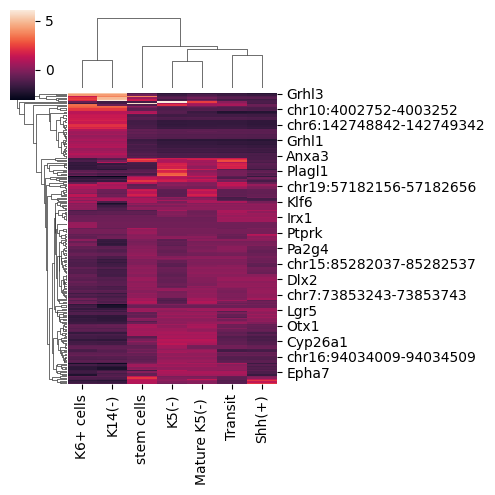

In [79]:
plt_df = s2c.get_scores(regex="min.+has_snp__zscore.*zscore$")
plt_df = plt_df.rename(columns=s2c.rename_column)

sns.clustermap(plt_df, figsize=(5, 5))
plt.savefig("../result/SNP/20250213_snp2cell_round1/20250213_GRN_hm.pdf")

In [76]:
plt_df.to_csv("../process/SNP/SNP2ell/20250213_heatmap_res_df.csv")

In [77]:
s2c.scores_prop.to_csv("../process/SNP/SNP2ell/20250213_snp2cell_prop_res_df.csv")

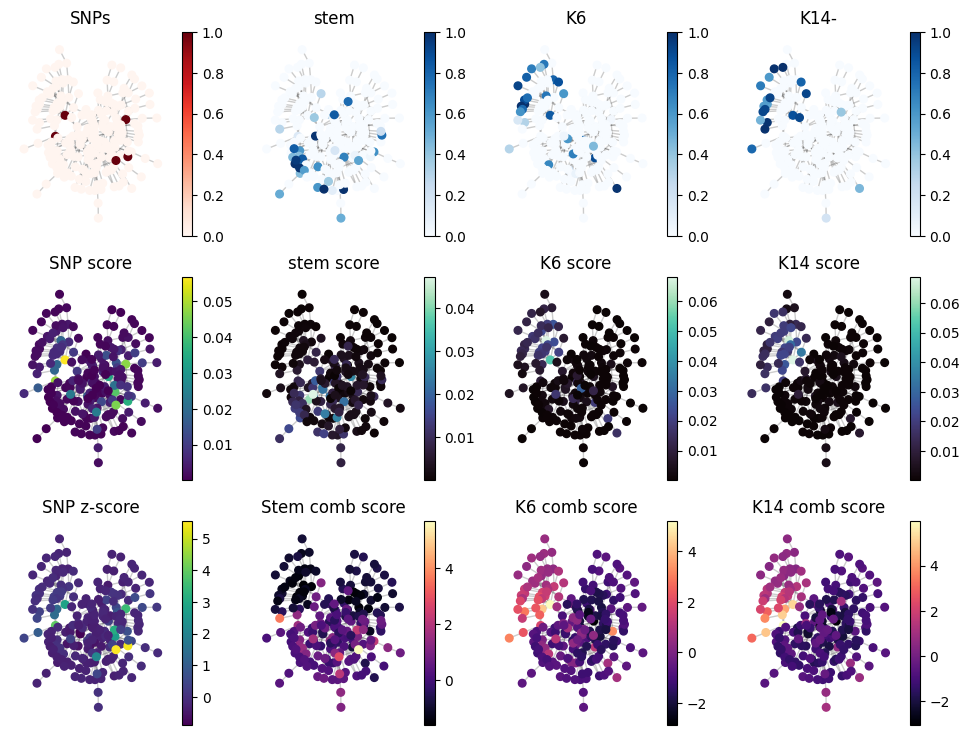

In [78]:
plot_scores = [
    (s2c.scores["has_snp"], "Reds", "SNPs"),
    (s2c.scores["DE_stem cells__score"], "Blues", "stem"),
    (s2c.scores["DE_K6+ cells__score"], "Blues", "K6"),
    (s2c.scores["DE_K14(-)__score"], "Blues", "K14-"),
    (s2c.scores_prop["has_snp"], "viridis", "SNP score"),
    (s2c.scores_prop["DE_stem cells__score"], "mako", "stem score"),
    (s2c.scores_prop["DE_K6+ cells__score"], "mako", "K6 score"),
    (s2c.scores_prop["DE_K14(-)__score"], "mako", "K14 score"),
    (s2c.scores_prop["has_snp__zscore"], "viridis", "SNP z-score"),
    (
        s2c.scores_prop["min(DE_stem cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Stem comb score",
    ),
    (
        s2c.scores_prop["min(DE_K6+ cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K6 comb score",
    ),
    (
        s2c.scores_prop["min(DE_K14(-)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K14 comb score",
    ),
]
nrow, ncol = 3, 4
plt.rcParams["figure.figsize"] = (ncol * 3, nrow * 3)
fig, axs = plt.subplots(nrow, ncol)
pos = nx.kamada_kawai_layout(G)
for k, (score_val, col_map, ax_title) in enumerate(plot_scores):
    i, j = int(k) // 4, k % 4
    ec = nx.draw_networkx_edges(G, pos, alpha=0.2, ax=axs[i, j])
    nc = nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=s2c.scores_prop.index.tolist(),
        node_color=score_val.tolist(),
        node_size=30,
        cmap=plt.colormaps[col_map],
        ax=axs[i, j],
    )
    plt.colorbar(nc)
    axs[i, j].set_title(ax_title)
    axs[i, j].axis("off")

plt.savefig("../result/SNP/20250213_snp2cell_round1/20250213_GRN_snp.pdf")